# Poda e hiperparâmetros

**Tema:** Aprendizado Supervisionado › Árvores de Decisão

Este notebook compara pré-poda (limitar hiperparâmetros antes do treino) e
pós-poda (`ccp_alpha`, crescer tudo e cortar depois), escolhe
hiperparâmetros por validação cruzada, e mede a invariância de árvores a
escalonamento — a promessa central do `teoria.pdf` que separa árvores dos
módulos anteriores.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

rng = np.random.default_rng(33)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Árvores são invariantes a escalonamento — confirmando

In [2]:
X, y = make_classification(n_samples=600, n_features=5, n_informative=4,
                           n_redundant=0, random_state=0)
X_escalonado_arbitrario = X * np.array([1, 1000, 0.001, 50, 1])  # escalas bem diferentes

acc_original = cross_val_score(DecisionTreeClassifier(random_state=0), X, y, cv=5).mean()
acc_escalonado = cross_val_score(
    DecisionTreeClassifier(random_state=0), X_escalonado_arbitrario, y, cv=5).mean()

print(f"acurácia (features originais)         : {acc_original:.6f}")
print(f"acurácia (features em escalas malucas): {acc_escalonado:.6f}")
print(f"\ndiferença: {abs(acc_original - acc_escalonado):.2e}   "
      f"(deveria ser ~0 — invariância a escala)")

acc_knn_original = cross_val_score(KNeighborsClassifier(), X, y, cv=5).mean()
acc_knn_escalonado = cross_val_score(
    KNeighborsClassifier(), X_escalonado_arbitrario, y, cv=5).mean()
print(f"\npara comparação, k-NN (módulo 4) SOFRE com a mesma escala maluca:")
print(f"acurácia k-NN (original) : {acc_knn_original:.4f}")
print(f"acurácia k-NN (escalonado): {acc_knn_escalonado:.4f}")

acurácia (features originais)         : 0.906667
acurácia (features em escalas malucas): 0.906667

diferença: 0.00e+00   (deveria ser ~0 — invariância a escala)

para comparação, k-NN (módulo 4) SOFRE com a mesma escala maluca:
acurácia k-NN (original) : 0.9617
acurácia k-NN (escalonado): 0.5933


## 2. Pré-poda: escolhendo max_depth e min_samples_leaf por CV

In [3]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=0)

grade = {"max_depth": [2, 3, 4, 5, 7, 10, None],
        "min_samples_leaf": [1, 5, 10, 20]}
busca = GridSearchCV(DecisionTreeClassifier(random_state=0), grade, cv=5).fit(X_treino, y_treino)

print(f"melhores hiperparâmetros: {busca.best_params_}")
print(f"melhor acurácia (5-fold): {busca.best_score_:.4f}")
print(f"acurácia no teste com esses hiperparâmetros: {busca.score(X_teste, y_teste):.4f}")

modelo_sem_poda = DecisionTreeClassifier(random_state=0).fit(X_treino, y_treino)
print(f"\nacurácia no teste SEM nenhuma restrição: {modelo_sem_poda.score(X_teste, y_teste):.4f}")
print(f"nº de folhas SEM restrição: {modelo_sem_poda.get_n_leaves()}   "
      f"nº de folhas COM os melhores hiperparâmetros: "
      f"{busca.best_estimator_.get_n_leaves()}")

melhores hiperparâmetros: {'max_depth': 4, 'min_samples_leaf': 1}
melhor acurácia (5-fold): 0.9167
acurácia no teste com esses hiperparâmetros: 0.8556

acurácia no teste SEM nenhuma restrição: 0.8722
nº de folhas SEM restrição: 34   nº de folhas COM os melhores hiperparâmetros: 13


## 3. Pós-poda: o caminho de custo-complexidade

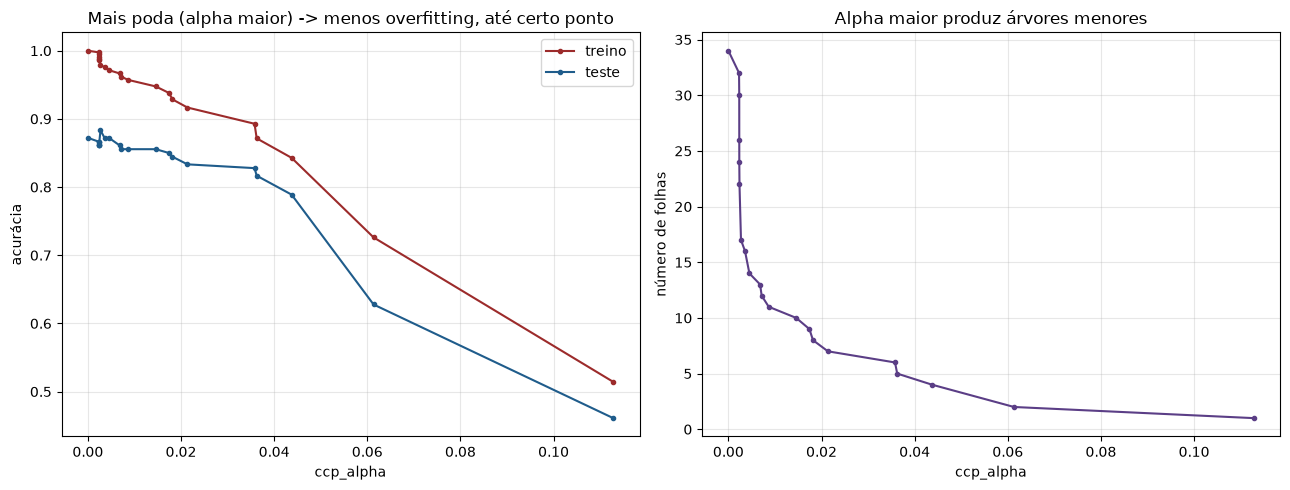

alpha que maximiza acurácia no teste: 0.00271
(na prática, escolha esse alpha por validação cruzada, nunca olhando
 o teste diretamente — tema 3, o mesmo princípio de vazamento)


In [4]:
caminho = DecisionTreeClassifier(random_state=0).cost_complexity_pruning_path(
    X_treino, y_treino)
alphas, impurezas = caminho.ccp_alphas, caminho.impurities

acc_treino_poda, acc_teste_poda, n_folhas = [], [], []
for alpha in alphas:
    modelo = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha).fit(X_treino, y_treino)
    acc_treino_poda.append(modelo.score(X_treino, y_treino))
    acc_teste_poda.append(modelo.score(X_teste, y_teste))
    n_folhas.append(modelo.get_n_leaves())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(alphas, acc_treino_poda, "o-", color=VERMELHO, label="treino", ms=3)
axes[0].plot(alphas, acc_teste_poda, "o-", color=AZUL, label="teste", ms=3)
axes[0].set_xlabel("ccp_alpha"); axes[0].set_ylabel("acurácia")
axes[0].set_title("Mais poda (alpha maior) -> menos overfitting, até certo ponto")
axes[0].legend()

axes[1].plot(alphas, n_folhas, "o-", color=ROXO, ms=3)
axes[1].set_xlabel("ccp_alpha"); axes[1].set_ylabel("número de folhas")
axes[1].set_title("Alpha maior produz árvores menores")
plt.tight_layout(); plt.show()

melhor_alpha = alphas[np.argmax(acc_teste_poda)]
print(f"alpha que maximiza acurácia no teste: {melhor_alpha:.5f}")
print(f"(na prática, escolha esse alpha por validação cruzada, nunca olhando")
print(f" o teste diretamente — tema 3, o mesmo princípio de vazamento)")

## 4. Pré-poda vs. pós-poda: comparação final

In [5]:
# pós-poda com alpha escolhido por CV (não pelo teste, corrigindo o "atalho" acima)
scores_por_alpha = [cross_val_score(
    DecisionTreeClassifier(random_state=0, ccp_alpha=a), X_treino, y_treino, cv=5).mean()
    for a in alphas]
alpha_por_cv = alphas[np.argmax(scores_por_alpha)]

modelo_pos_poda = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha_por_cv).fit(
    X_treino, y_treino)

print(f"{'estratégia':<30s} {'acc teste':>12s} {'nº folhas':>12s}")
print("-" * 56)
print(f"{'sem restrição':<30s} {modelo_sem_poda.score(X_teste, y_teste):>12.4f} "
      f"{modelo_sem_poda.get_n_leaves():>12d}")
print(f"{'pré-poda (grid search)':<30s} {busca.score(X_teste, y_teste):>12.4f} "
      f"{busca.best_estimator_.get_n_leaves():>12d}")
print(f"{'pós-poda (ccp_alpha por CV)':<30s} {modelo_pos_poda.score(X_teste, y_teste):>12.4f} "
      f"{modelo_pos_poda.get_n_leaves():>12d}")

estratégia                        acc teste    nº folhas
--------------------------------------------------------
sem restrição                        0.8722           34
pré-poda (grid search)               0.8556           13
pós-poda (ccp_alpha por CV)          0.8722           14


## O que levar deste notebook

- Árvores são genuinamente invariantes a escalonamento — a mesma
  transformação que destrói k-NN não muda em nada uma árvore.
- Pré-poda (limitar hiperparâmetros antes) e pós-poda (`ccp_alpha`, cortar
  depois de crescer tudo) resolvem o mesmo problema de formas diferentes —
  ambas exigem validação cruzada para escolher a força certa.
- "Sem restrição" sempre tem MAIS folhas que as árvores podadas (34 contra
  13-14 neste exemplo) — a poda alcança desempenho de teste igual ou
  comparável com um modelo muito mais simples e interpretável. O
  desempenho de teste em uma única divisão pode até empatar ou favorecer
  levemente a árvore sem restrição por sorte de amostra (como aconteceu
  aqui na pré-poda) — é exatamente por isso que a comparação séria usa
  validação cruzada (tema 6), não uma única divisão treino/teste.

→ Próximo: o notebook de **exercícios** do módulo.